## STUDENT NAME: __  ID: __
## PARTNER NAME: __  ID: __
[Check audio files](#Check-all-audio-files)\
[STFT single file](#Experiment-with-a-single-file-using-STFT-to-extract-feature)\
[STFT multiple files](#Experiment-with-files-of-the-same-sentence-but-different-emotions)\
[MFCC 20x301](#Experiment-with-Mel-frequency-cepstral-coefficients-(MFCC)(20x301))\|
[MFCC 40x301](#MFCC-Features-(40x301))\
[Create Dataset](#Construct-dataset-table)

In [1]:
import librosa
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import platform
import glob

In [2]:
is_mac = platform.system() == "Darwin"
is_windows = platform.system() == "Windows"

if is_mac:
    BASE_PATH = Path.home() / "crema-d-mirror"
elif is_windows:
    BASE_PATH = Path(r"E:\CREMA-D")   # adjust if needed
else:
    BASE_PATH = Path.cwd()

AUDIO_PATH = BASE_PATH / "AudioMP3"
PROCESSED_PATH = BASE_PATH / "processedResults"

print("Using base path:", BASE_PATH)
print("Audio path:", AUDIO_PATH)

Using base path: E:\CREMA-D
Audio path: E:\CREMA-D\AudioMP3


# Check all audio files

In [3]:
df = {"file_name":[], "duration":[], "sampling_rate":[]}
for fn in glob.glob( str(AUDIO_PATH/"*.mp3"), recursive=True):
    df['file_name'].append(fn)
    df['sampling_rate'].append(librosa.get_samplerate(path=fn))
    df['duration'].append(librosa.get_duration(path=fn))

In [4]:
df = pd.DataFrame(df)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7442 entries, 0 to 7441
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   file_name      7442 non-null   str    
 1   duration       7442 non-null   float64
 2   sampling_rate  7442 non-null   int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 174.6 KB


In [6]:
df.describe()

,duration,sampling_rate
count,7442.000000,7442.0
mean,2.586781,44100.0
std,0.857171,0.0
min,0.092494,44100.0
25%,2.234535,44100.0
50%,2.521882,44100.0
75%,2.861474,44100.0
max,61.793719,44100.0


<Axes: >

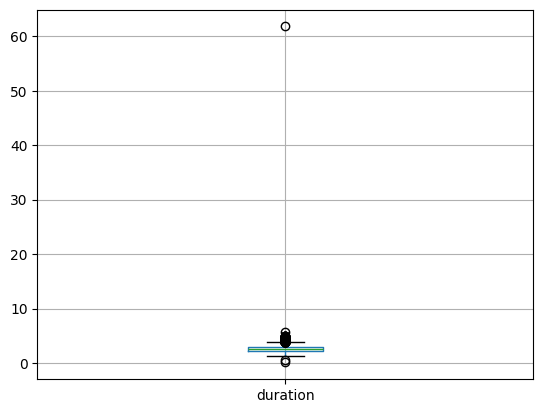

In [7]:
df.boxplot('duration')

In [9]:
df.hist('duration', log=True, bins=100)

array([[<Axes: title={'center': 'duration'}>]], dtype=object)

In [10]:
Q1 = df['duration'].quantile(0.25)
Q3 = df['duration'].quantile(0.75)
IQR = Q3 - Q1
lo_limit = Q1 - IQR * 1.5
hi_limit = Q3 + IQR * 1.5

In [11]:
df[df['duration'] < lo_limit]

,file_name,duration,sampling_rate
5216,E:\CREMA-D\AudioMP3\1064_TIE_SAD_XX.mp3,0.588821,44100
6186,E:\CREMA-D\AudioMP3\1076_MTI_NEU_XX.mp3,0.092494,44100


In [12]:
Q3 + IQR * 1.5

np.float64(3.8018820861678)

In [13]:
df[df['duration'] > 50]

,file_name,duration,sampling_rate
5158,E:\CREMA-D\AudioMP3\1064_IEO_DIS_MD.mp3,61.793719,44100


In [14]:
df[df['duration'] > hi_limit]

,file_name,duration,sampling_rate
111,E:\CREMA-D\AudioMP3\1002_ITH_DIS_XX.mp3,3.828005,44100
192,E:\CREMA-D\AudioMP3\1003_ITH_DIS_XX.mp3,4.063107,44100
195,E:\CREMA-D\AudioMP3\1003_ITH_NEU_XX.mp3,4.063107,44100
204,E:\CREMA-D\AudioMP3\1003_IWL_DIS_XX.mp3,4.428821,44100
206,E:\CREMA-D\AudioMP3\1003_IWL_HAP_XX.mp3,3.932494,44100
...,...,...,...
7273,E:\CREMA-D\AudioMP3\1089_WSI_DIS_XX.mp3,4.089229,44100
7331,E:\CREMA-D\AudioMP3\1090_MTI_DIS_XX.mp3,3.828005,44100
7343,E:\CREMA-D\AudioMP3\1090_TIE_DIS_XX.mp3,4.036984,44100
7347,E:\CREMA-D\AudioMP3\1090_TIE_SAD_XX.mp3,3.854127,44100


In [15]:
df[df['duration'] > 3]

,file_name,duration,sampling_rate
40,E:\CREMA-D\AudioMP3\1001_IWL_ANG_XX.mp3,3.201066,44100
52,E:\CREMA-D\AudioMP3\1001_MTI_ANG_XX.mp3,3.044331,44100
64,E:\CREMA-D\AudioMP3\1001_TIE_ANG_XX.mp3,3.122698,44100
69,E:\CREMA-D\AudioMP3\1001_TIE_SAD_XX.mp3,3.070454,44100
91,E:\CREMA-D\AudioMP3\1002_IEO_DIS_HI.mp3,3.044331,44100
...,...,...,...
7407,E:\CREMA-D\AudioMP3\1091_IWW_DIS_XX.mp3,3.044331,44100
7409,E:\CREMA-D\AudioMP3\1091_IWW_HAP_XX.mp3,3.044331,44100
7413,E:\CREMA-D\AudioMP3\1091_MTI_DIS_XX.mp3,3.044331,44100
7425,E:\CREMA-D\AudioMP3\1091_TIE_DIS_XX.mp3,3.801882,44100


# Experiment with a single file using STFT to extract feature

In [16]:
audio_filename = "1001_DFA_ANG_XX.mp3"
audio_sample = Path(AUDIO_PATH) / audio_filename

In [17]:
# Load MP3 file with a sampling rate of 22.05 kHz (MP3 file has a sampling rate of 44.1 kHz)
# reference: https://github.com/GeWu-Lab/OGM-GE_CVPR2022/blob/main/dataset/CramedDataset.py
samples, rate = librosa.load(audio_sample, sr=22050)

In [18]:
# Check audio length:
print("%s: %.4f seconds, number of samples: %d" % (audio_filename, len(samples) / 22050, len(samples)))

1001_DFA_ANG_XX.mp3: 2.2607 seconds, number of samples: 49848


In [19]:
# Repeat sample audio 3 times then keep the last 3 seconds of audio
# Clip audio between 1 and -1.
# reference: https://github.com/GeWu-Lab/OGM-GE_CVPR2022/blob/main/dataset/CramedDataset.py
resamples = np.tile(samples, 3)[:22050*3]
resamples[resamples > 1.] = 1.
resamples[resamples < -1.] = -1.

In [20]:
plt.plot(np.arange(len(resamples)) / 22050, resamples)
plt.title(f"{audio_filename}, padded to 3 seconds")
plt.xlabel('Time(s)')
plt.ylabel('Amplitude')

Text(0, 0.5, 'Amplitude')

In [21]:
# Check resampled audio length:
print("%s (resampled): %.4f seconds, number of samples: %d" % (audio_filename, len(resamples) / 22050, len(resamples)))

1001_DFA_ANG_XX.mp3 (resampled): 3.0000 seconds, number of samples: 66150


In [22]:
# Choose hop length 220 to match the 299 time frames
# Each time frame contains 512 audio samples in time, of which, 512 - 220 = 292 samples are overlapping between each adjacent window
# There are a total of 257 frequency bins.
spectrogram = librosa.stft(resamples, n_fft=512, hop_length=220, center=False)

In [23]:
# Get magnitude and add a small number to avoid log(0)
spectrogram = np.log(np.abs(spectrogram) + 1e-7)

In [24]:
print("rows: %d, cols: %d " % (len(spectrogram), len(spectrogram[0])))

rows: 257, cols: 299 


In [25]:
# Display spectrogram
fig, ax = plt.subplots()
img = librosa.display.specshow(spectrogram, y_axis='log', x_axis='time', ax=ax, sr=22050, hop_length=220)
ax.set_title('Power spectrogram')
fig.colorbar(img, ax=ax, format="%+2.0f dB")

# Experiment with files of the same sentence but different emotions

In [26]:
audio_filenames = ["1001_DFA_ANG_XX.mp3", "1001_DFA_DIS_XX.mp3", "1001_DFA_FEA_XX.mp3", "1001_DFA_HAP_XX.mp3", "1001_DFA_NEU_XX.mp3","1001_DFA_SAD_XX.mp3"]
audio_samples = [Path(AUDIO_PATH) / audio_filename for audio_filename in audio_filenames]

In [27]:
all_samples = [librosa.load(audio_sample, sr=22050)[0] for audio_sample in audio_samples]

In [28]:
all_resamples = [np.clip(np.tile(samples, 3)[:22050*3], -1.0, 1.0) for samples in all_samples]

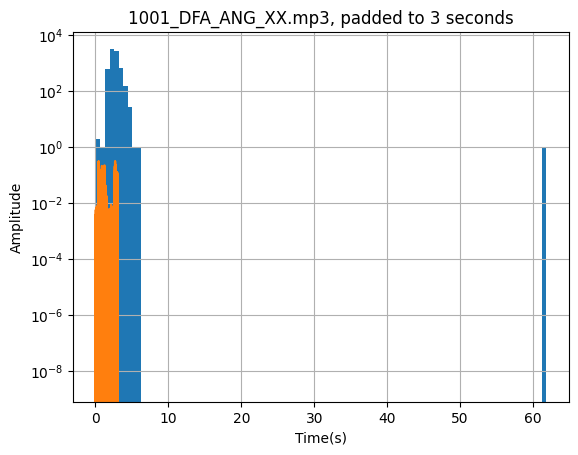

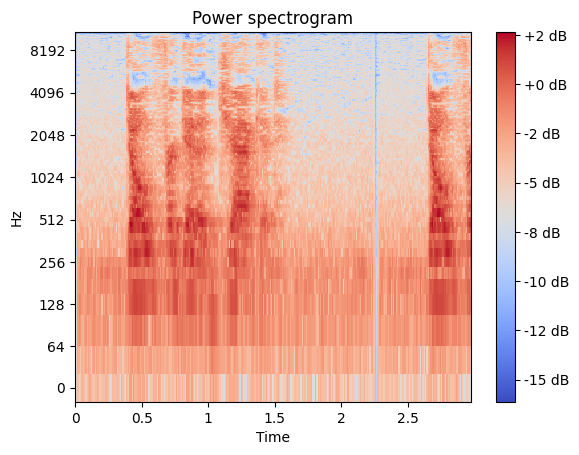

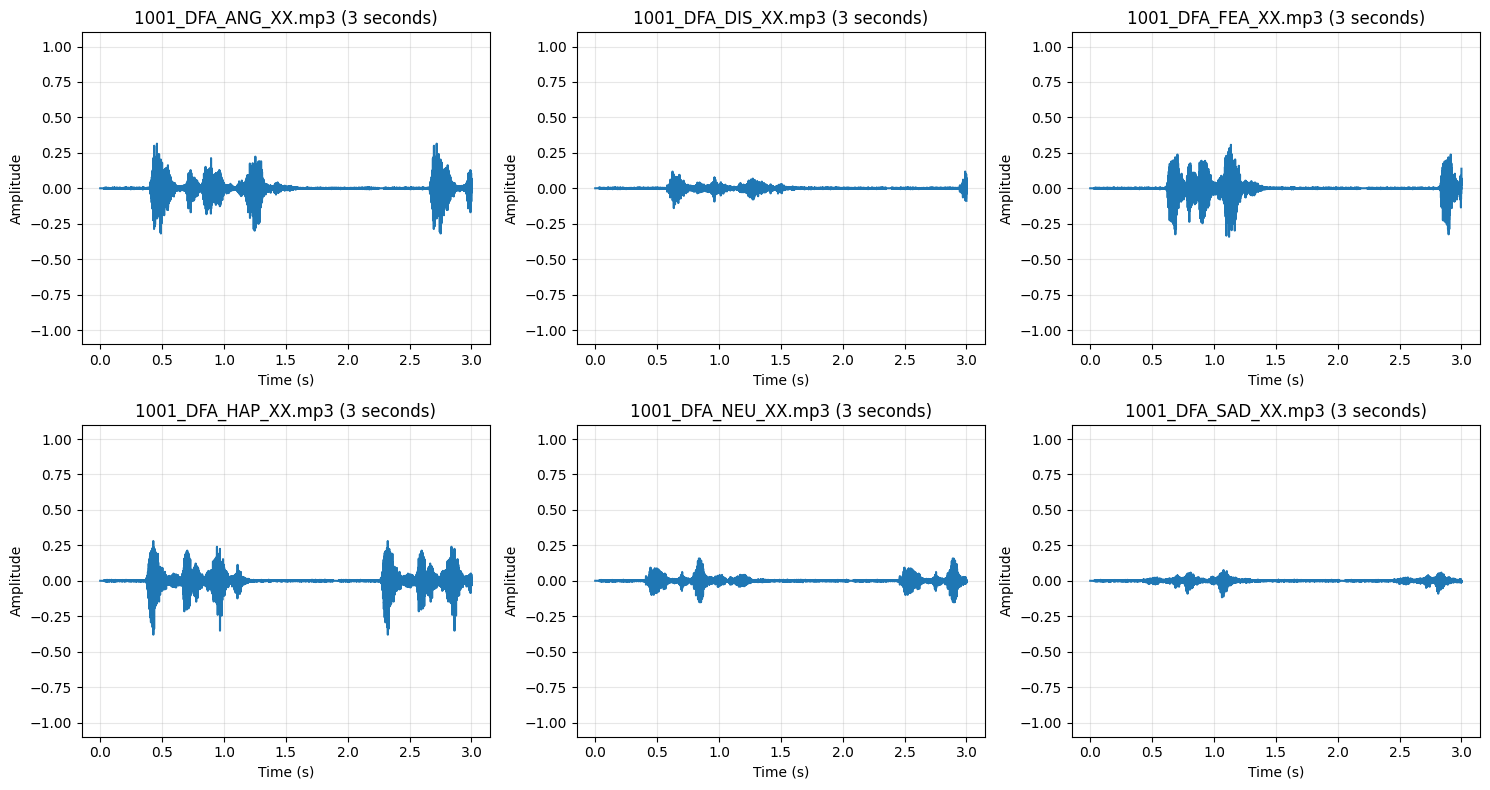

In [29]:
n_files = len(all_resamples)
n_rows = (n_files + 2) // 3  # Ceiling division for 3 columns
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4*n_rows))
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, (resamples, filename) in enumerate(zip(all_resamples, audio_filenames)):
    time = np.arange(len(resamples)) / 22050
    axes[i].plot(time, resamples)
    axes[i].set_title(f"{filename} (3 seconds)")
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(-1.1, 1.1)

for i in range(len(all_resamples), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [30]:
all_spectrograms = [librosa.stft(resamples, n_fft=512, hop_length=220, center=False) for resamples in all_resamples]

In [31]:
all_spectrograms = [np.log(np.abs(spectrogram) + 1e-7) for spectrogram in all_spectrograms]

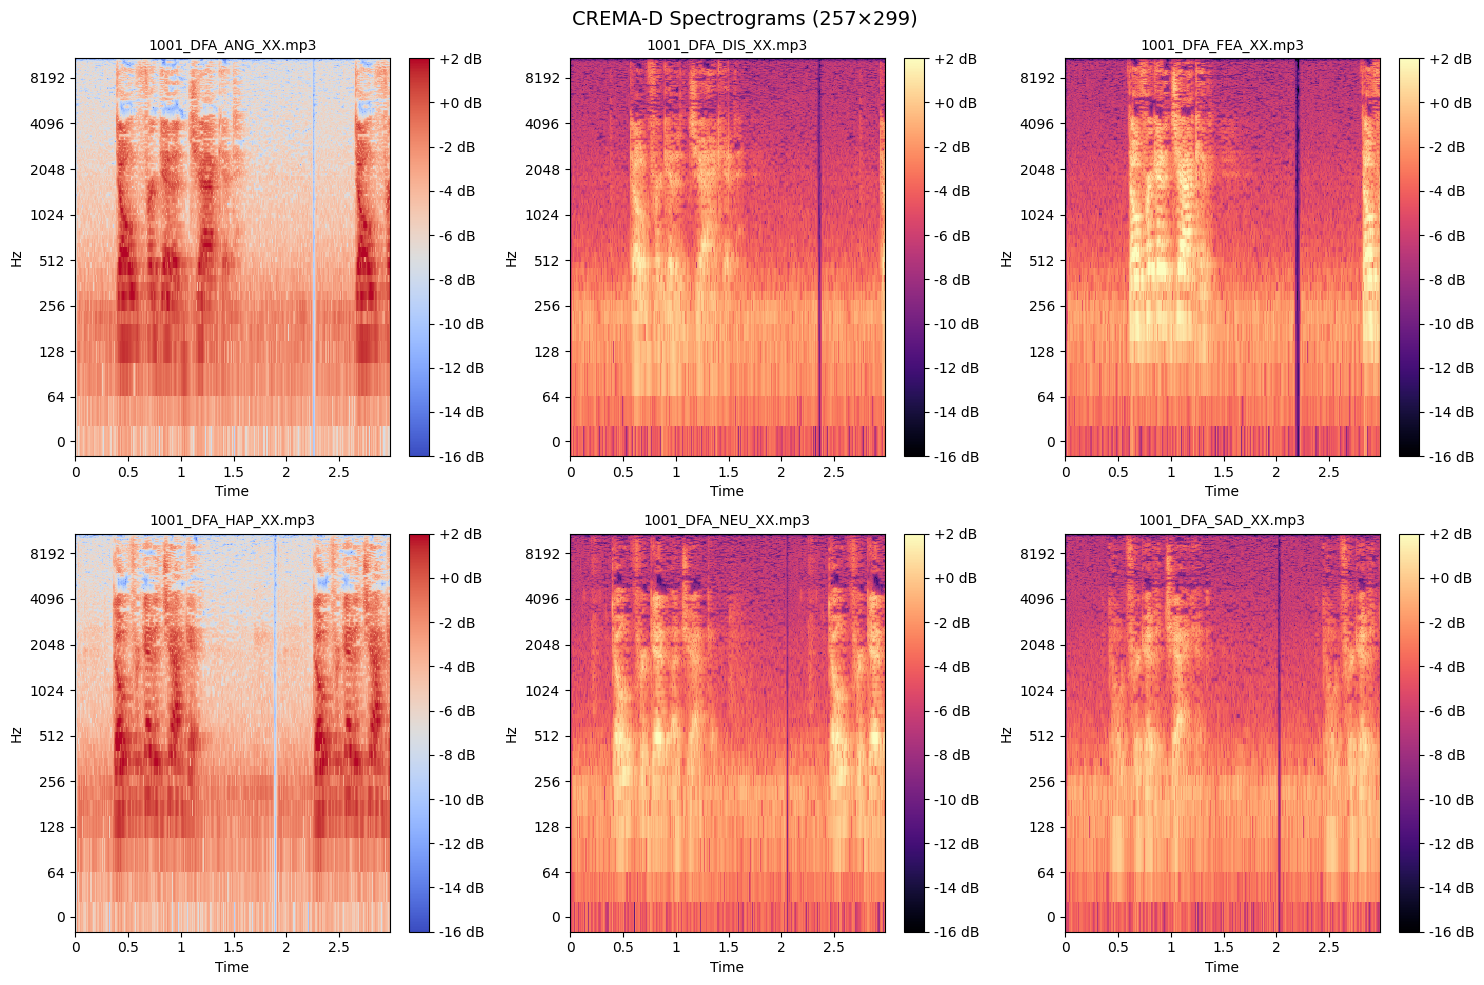

In [32]:
n_files = len(all_spectrograms)
n_cols = 3
n_rows = (n_files + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, (spectrogram, filename) in enumerate(zip(all_spectrograms, audio_filenames)):
    img = librosa.display.specshow(spectrogram, 
                                   y_axis='log', 
                                   x_axis='time', 
                                   ax=axes[i], 
                                   sr=22050, 
                                   hop_length=220,
                                   vmin=-16, vmax=2,
                                  )
    axes[i].set_title(f'{filename}', fontsize=10)
    fig.colorbar(img, ax=axes[i], format="%+2.0f dB")

# Hide unused subplots
for i in range(len(all_spectrograms), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('CREMA-D Spectrograms (257×299)', fontsize=14)
plt.tight_layout()
plt.show()

# Experiment with Mel-frequency cepstral coefficients (MFCC)(20x301)

In [33]:
# default n_mfcc=20 (, n_mels=128 (filter banks)
all_mfcc = [librosa.feature.mfcc(y=resamples, sr=22050, n_fft=512, n_mfcc=20, hop_length=220) for resamples in all_resamples]

In [34]:
all_mfcc[1]

array([[-9.0257672e+02, -9.0257672e+02, -8.9947729e+02, ...,
        -4.3950436e+02, -4.3246783e+02, -3.4348694e+02],
       [ 0.0000000e+00,  0.0000000e+00,  5.4317701e-01, ...,
         1.6951582e+02,  1.9689417e+02,  1.1359998e+02],
       [ 0.0000000e+00,  0.0000000e+00, -1.0578693e+00, ...,
        -5.5969292e+01, -8.3238281e+01, -4.8496628e+01],
       ...,
       [ 0.0000000e+00,  0.0000000e+00, -1.1224732e+00, ...,
         6.1761580e+00,  1.0434272e+01,  1.4589500e+00],
       [ 0.0000000e+00,  0.0000000e+00,  1.2858260e+00, ...,
        -1.4402278e+01, -2.5126774e+01, -2.6312871e+00],
       [ 0.0000000e+00,  0.0000000e+00, -2.7503878e-02, ...,
         1.5036987e+00, -6.6678505e+00, -5.5397887e+00]],
      shape=(20, 301), dtype=float32)

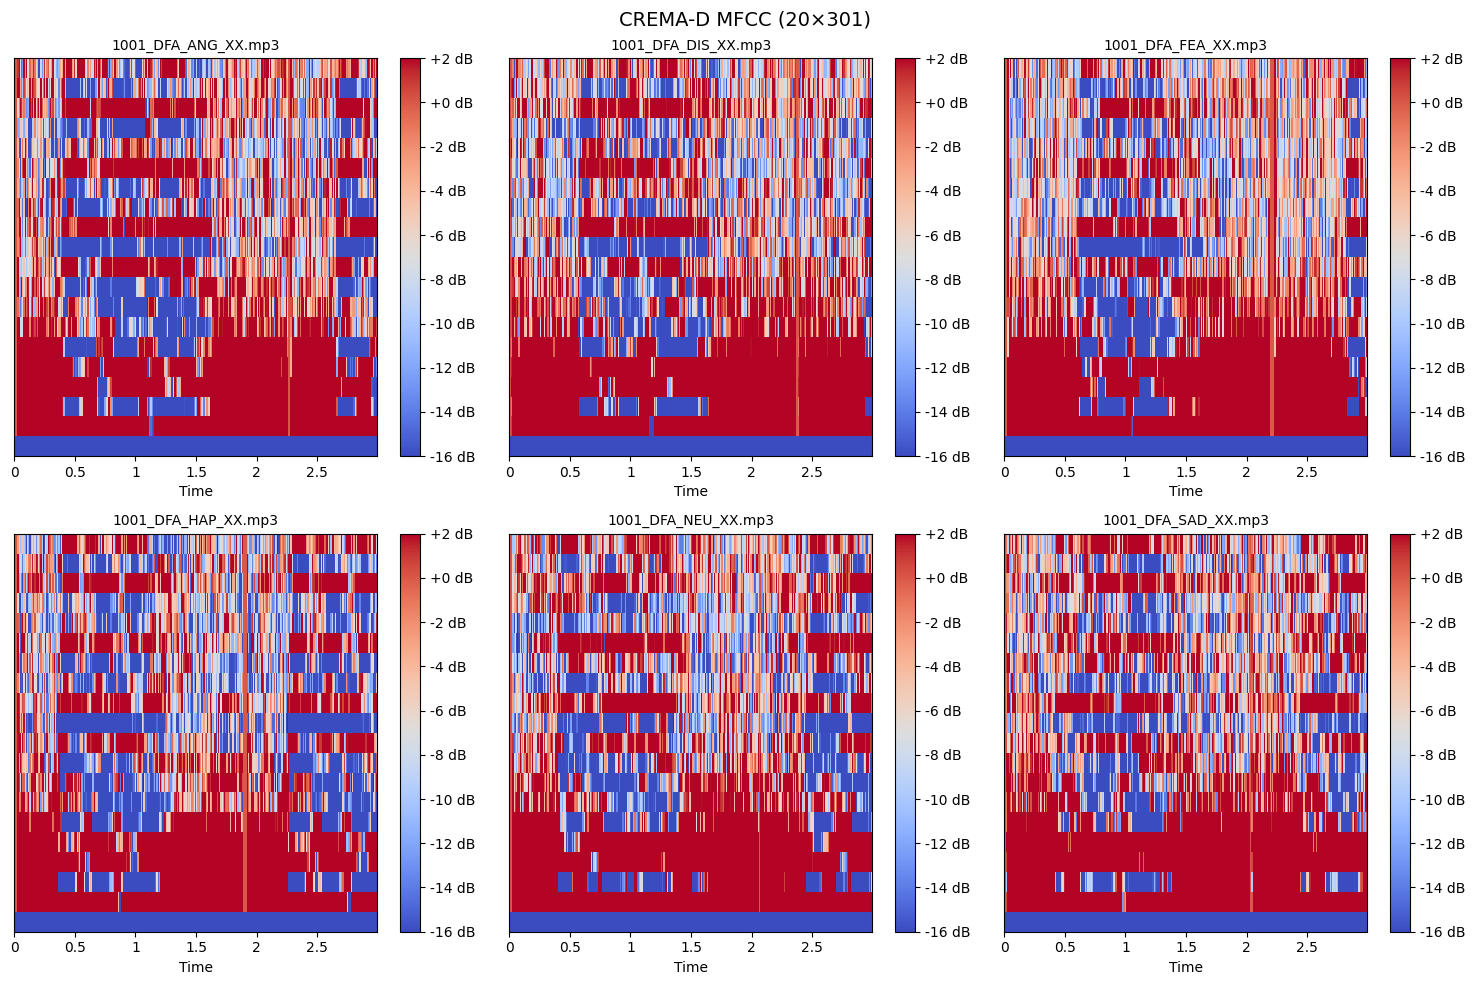

In [35]:
n_files = len(all_mfcc)
n_cols = 3
n_rows = (n_files + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, (mfcc, filename) in enumerate(zip(all_mfcc, audio_filenames)):
    img = librosa.display.specshow(mfcc, 
                                   #y_axis='log', 
                                   x_axis='time', 
                                   ax=axes[i], 
                                   sr=22050, 
                                   hop_length=220,
                                   vmin=-16, vmax=2
                                  )
    axes[i].set_title(f'{filename}', fontsize=10)
    fig.colorbar(img, ax=axes[i], format="%+2.0f dB")

# Hide unused subplots
for i in range(len(all_mfcc), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('CREMA-D MFCC (20×301)', fontsize=14)
plt.tight_layout()
plt.show()

# MFCC Features (40x301)

In [36]:
# default n_mfcc=20 (, n_mels=128 (filter banks)
all_mfcc = [librosa.feature.mfcc(y=resamples, sr=22050, n_fft=512, n_mfcc=40, hop_length=220) for resamples in all_resamples]

In [37]:
print("%d x %d" % (len(all_mfcc[0]), len(all_mfcc[0][0])))

40 x 301


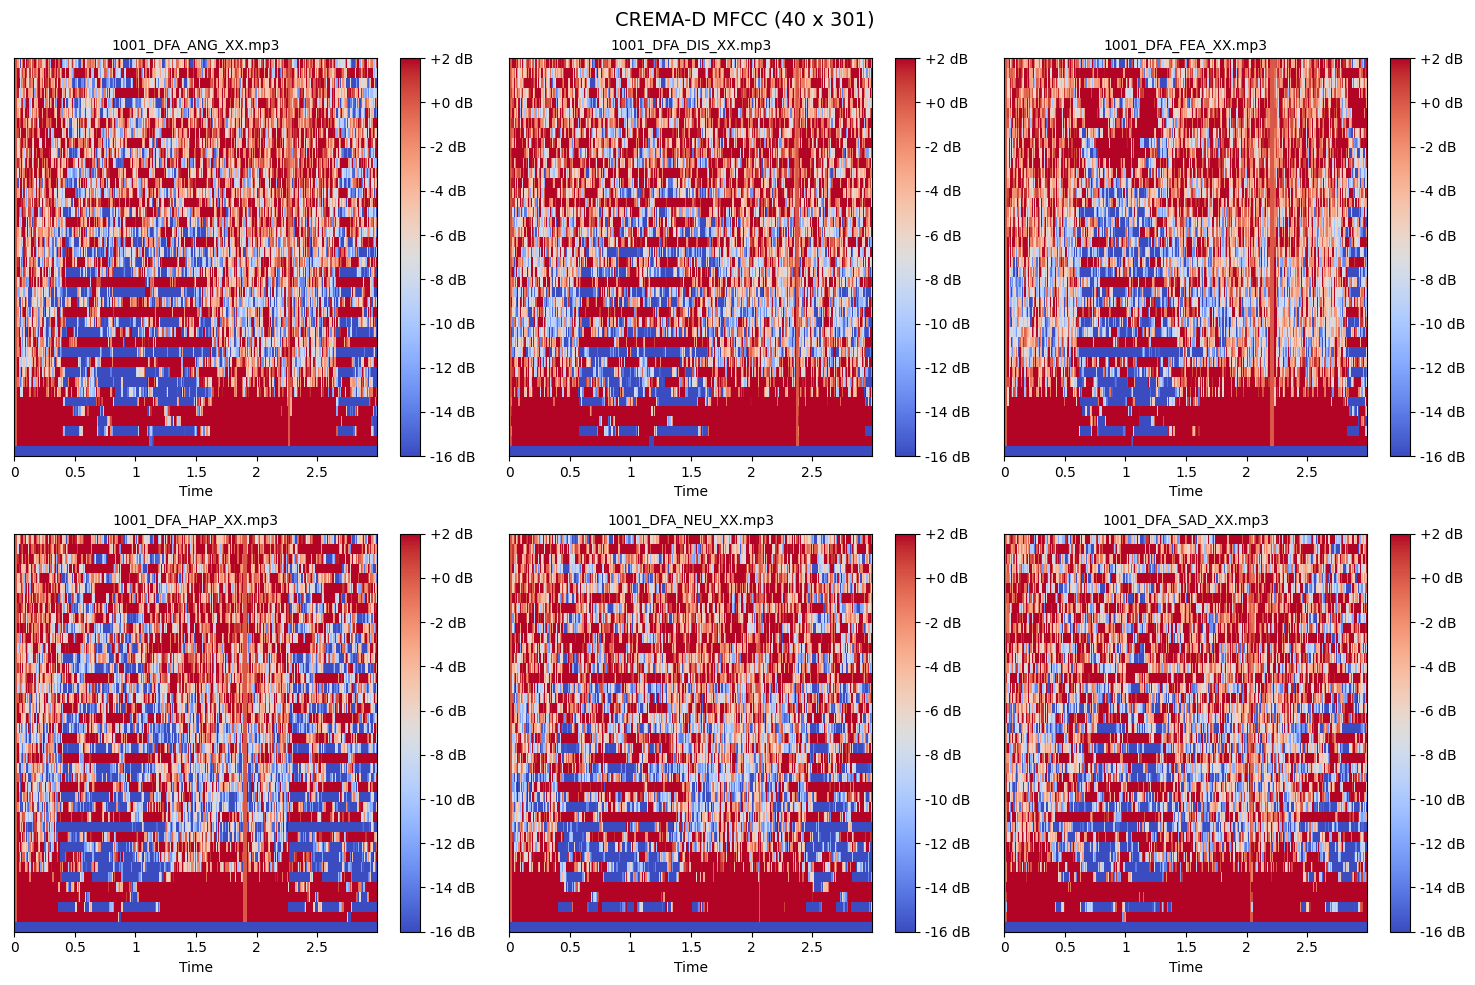

In [38]:
n_files = len(all_mfcc)
n_cols = 3
n_rows = (n_files + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, (mfcc, filename) in enumerate(zip(all_mfcc, audio_filenames)):
    img = librosa.display.specshow(mfcc, 
                                   #y_axis='log', 
                                   x_axis='time', 
                                   ax=axes[i], 
                                   sr=22050, 
                                   hop_length=220,
                                   vmin=-16, vmax=2,
                                  )
    axes[i].set_title(f'{filename}', fontsize=10)
    fig.colorbar(img, ax=axes[i], format="%+2.0f dB")

# Hide unused subplots
for i in range(len(all_mfcc), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('CREMA-D MFCC (40 x 301)', fontsize=14)
plt.tight_layout()
plt.show()

# Construct dataset table
#### Use summaryTable.csv to obtain emotion voting based on VoiceLevel column.
The dataset contains the following columns:
idx, FileName, Sentence, VotedEmotion, MFCC matrix 

In [39]:
# Load summary table
summary_df = pd.read_csv(Path(PROCESSED_PATH) / "summaryTable.csv")
emotion_map = {'A':'ANG','D':'DIS','F':'FEA','H':'HAP','N':'NEU','S':'SAD'}

In [40]:
n_by_m = {#"MFCC_20x301": {"num_features":  6020, "n_fft": 512, "n_mfcc": 20, "n_mels": 128, "hop_length": 220},
          #"MFCC_40x301": {"num_features": 12040, "n_fft": 512, "n_mfcc": 40, "n_mels": 128, "hop_length": 220},          
          "STFT_257x299":  {"num_features":   76843, "n_fft": 512, "hop_length": 220},}

for feature_name, params in n_by_m.items():
    data = []
    file_idx = 0
    for _, row in summary_df.iterrows():
        # Get emotion
        # If multiple votes are available, choose one with higher VoiceLevel.
        votes = str(row['VoiceVote']).split(':')
        levels = [float(x) for x in str(row['VoiceLevel']).split(':')] if ':' in str(row['VoiceLevel']) else [float(row['VoiceLevel'])]
        emotion = emotion_map.get(votes[np.argmax(levels)], row['VoiceVote'])
        
        # Load audio    
        audio_filename = row['FileName'] + '.mp3'
        audio_file = Path(AUDIO_PATH) / audio_filename
        y, sr = librosa.load(audio_file, sr=22050)
        
        # Process to 3 seconds and clip
        y = np.tile(y, 3)[:22050*3]
        y = np.clip(y, -1, 1)

        if "STFT" in feature_name:            
            stft = librosa.stft(y=y, n_fft=params["n_fft"], hop_length=params["hop_length"], center=False)     
            m = np.log(np.abs(stft) + 1e-7)
        elif "MFCC" in feature_name:
            m = librosa.feature.mfcc(y=y, sr=sr, n_fft=params["n_fft"], hop_length=params["hop_length"], 
                                     n_mels=params["n_mels"], n_mfcc=params["n_mfcc"])
        else:
            break

        # Corrupted files that after repeating 3 times are still less than 3 seconds, remove them from the process.
        if len(m.flatten()) != params["num_features"]:
            print(row['FileName'])
        else:    
            # show progress
            if file_idx != int(audio_filename.split('_')[0]):
                file_idx = int(audio_filename.split('_')[0])
                print(feature_name, file_idx)
            data.append({'filename': row['FileName'], 'emotion': emotion, 'features': m.flatten()})
    # save to npz
    X = np.vstack([item['features'] for item in data])  # Features
    y = np.array([item['emotion'] for item in data])  # Labels
    filenames = np.array([item['filename'] for item in data])  # Filenames
    np.savez(f'crema_data_{feature_name}.npz', 
             features=X, 
             emotions=y, 
             filenames=filenames)

STFT_257x299 1001
STFT_257x299 1002
STFT_257x299 1003
STFT_257x299 1004
STFT_257x299 1005
STFT_257x299 1006
STFT_257x299 1007
STFT_257x299 1008
STFT_257x299 1009
STFT_257x299 1010
STFT_257x299 1011
STFT_257x299 1012
STFT_257x299 1013
STFT_257x299 1014
STFT_257x299 1015
STFT_257x299 1016
STFT_257x299 1017
STFT_257x299 1018
STFT_257x299 1019
STFT_257x299 1020
STFT_257x299 1021
STFT_257x299 1022
STFT_257x299 1023
STFT_257x299 1024
STFT_257x299 1025
STFT_257x299 1026
STFT_257x299 1027
STFT_257x299 1028
STFT_257x299 1029
STFT_257x299 1030
STFT_257x299 1031
STFT_257x299 1032
STFT_257x299 1033
STFT_257x299 1034
STFT_257x299 1035
STFT_257x299 1036
STFT_257x299 1037
STFT_257x299 1038
STFT_257x299 1039
STFT_257x299 1040
STFT_257x299 1041
STFT_257x299 1042
STFT_257x299 1043
STFT_257x299 1044
STFT_257x299 1045
STFT_257x299 1046
STFT_257x299 1047
STFT_257x299 1048
STFT_257x299 1049
STFT_257x299 1050
STFT_257x299 1051
STFT_257x299 1052
STFT_257x299 1053
STFT_257x299 1054
STFT_257x299 1055
STFT_257x2

In [41]:
# data[0]

In [42]:
# # Default is 20 x 301 features
# X = np.vstack([item['mfcc'] for item in data])  # Features
# y = np.array([item['emotion'] for item in data])  # Labels
# filenames = np.array([item['filename'] for item in data])  # Filenames

In [43]:
# np.savez('crema_data.npz', 
#          features=X, 
#          emotions=y, 
#          filenames=filenames)

In [44]:
# File size comparson: 
#
# crema_data_MFCC_20x301.npz,   175 MB
# crema_data_MFCC_40x301.npz,   350 MB
# crema_data_STFT_257x299.npz,  4.4 GB

In [45]:
data_file = "crema_data_MFCC_20x301.npz"
banner = "Training Result"